# Objectif du notebook 

Date de création : 10/12/2025

L'objectif du notebook est de repositionner les OBS de la campagne de mesure du mois d'octobre 2025 à Groix dans le cadre du projet Fiberscope. 
Les OBS ont été déployés proche de la fibre reliant le continent à l'île de Groix. Leurs positions sont connues a priori (relèvement de la position GPS et position visée). 

Ce notebook vise à mettre en œuvre les outils nécessaires à l'inversion des positions sur un jeu de données fictives. Ces outils seront ensuite utilisés sur les données réelles dans un second notebook. 

## Approche générale 

Les positions des capteurs sont inversées par résolution d'un système de moindres carrés non linéaires formulé en fonction des : 

* 1) mesures des temps d'arrivée (TOA) dans le cas des émissions actives avec la source Lubell 
* 2) mesures des différences de temps d'arrivée (TDOA) dans le cas de l'exploitation de sources d'opportunités (bruit rayonné par les navires circulant dans la zone durant la campagne et dont la position est relevée par le système AIS)

### Définition du repère de référence 
Avant de mettre en œuvre le schéma d'inversion il est nécessaire de définir le repère de référence dans lequel on souhaite exprimer l'ensemble des coordonnées. 

Les positions de la source sont données par les données de l'antenne GPS à bord du navire. En positionnement standard le GPS fourni des positions dans le repère de référence WGS84. L'exactitude de ce positionnement est au mieux métrique. 

Quelques codes EPSG associés au WGS84 (cours géodésie Bosser p.92):
* 4978 : pour l’expression de coordonnées ECEF dans le WGS84
* 4326 : pour l’expression de coordonnées géographiques dans le WGS84


### Inversion des TOAs
L'approche la plus simple consiste à exploiter les TOAs. Le système des moindres carrés est exprimé en fonction de la distance de propagation au carré :

$$
y_k = d^2 = c^2 t_k^2
$$
 
où $t_k$ est le temps d'arrivée du direct pour la $k$-ème position de la source et $c$ est la célérité de référence (célérité moyenne, célérité équivalente).

Remarque : l'utilisation de la distance au carré permet de ne pas se trimbaler la racine pour le calcul de la matrice Jacobienne. 

<!-- 
On note $X_k$ la position 
$$
D_j^2 = \lVert P_jH_1\rVert^2 = (r_j - r)^2 + (z-z_j)^2 = (r_j - r)^2 + z^2   
$$

Pour la position de référence (j=0) : 

$$
(1) \quad \quad D_0^2 = (r_0 - r)^2 + z^2 = r_0^2 - 2r_0r + z^2  = z^2
$$

Or on peut écrire pour $j \in [1, 5]$ :

$$
(2) \quad \quad D_j^2 = (D_0 + \delta D_j)^2 = D_0^2 + 2D_0 \delta D_j + D_j^2
$$

Et, 

$$
(3) \quad \quad  D_0^2 + 2D_0 \delta D_j + D_j^2 =  r_j^2 - 2r_jr + z^2 
$$

Ainsi, on peut écrire (3) - (2) : 

$$
(4) \quad \quad  2D_0 \delta D_j + D_j^2 =  r_j^2 - 2r_jr
$$
 -->


In [157]:
import os 
import sys 
import arlpy
import numpy as np 
import xarray as xr
import pandas as pd
import scipy.signal as sp
import matplotlib.pyplot as plt  

sys.path.append(r"C:\Users\baptiste.menetrier\Desktop\devPy\phd")

from real_data_analysis.fiberscope_groix.src.utils_geo import (
    geodetic_to_ecef,
    ecef_to_enu,
    enu_to_ecef, 
    ecef_to_geodetic,
)


from real_data_analysis.fiberscope_20.src import  params
from misc import equivalent_celerity, calc_wls, draw_ellipse
from real_data_analysis.fiberscope_20.src.fiberscope_manager import FiberscopeManager
from real_data_analysis.fiberscope_20.src.fiberscope_recording import (
    FiberscopeSweep1,
    # FiberscopeSweep2,
)
from real_data_analysis.fiberscope_20.src.utils import (
    all_arrivals_static,
    direct_arrival_env,
    f_d2,
    # f_d2_no_z,
    jac_d2,
    # jac_d2_no_z,
)

from publication.publication_figure import PubFigure, color

In [158]:
root_groix_data = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\data\fiberscope_groix_oct_2025"
root_groix_wav = os.path.join(root_groix_data, "wav")
root_groix_metadata = os.path.join(root_groix_data, "metadata")

# Définition du repère local 

## Chargement des positions a priori des OBS et des points d'émission statique. Les coordonnées sont a priori en WGS84.

In [159]:
# Chargement des positions a priori
apriori_pos_wgs84 = pd.read_csv(os.path.join(root_groix_metadata, "pos_deg.csv"), index_col=0)
# Ajout d'une hauteur (aléatoire pour l'instant)
# En vrai il faut surement chercher la hauteur du géoid au dessus de l'éllispoid WGS84
# et y retrancher l'immersion du capteur (immersion par rapport au niveau moyen de la mer donnée par
# la moyenne des mesures de pression du capteur de pression).
apriori_pos_wgs84["h"] = -25 + np.random.normal(
    loc=0, scale=1, size=apriori_pos_wgs84.shape[0]
)

In [160]:
apriori_pos_wgs84

,lat,lon,h
id,,,
obs1,47.661667,-3.470000,-23.447153
obs2,47.669167,-3.464167,-24.228515
obs3,47.676667,-3.460000,-25.667548
t1,47.661667,-3.467500,-23.965342
t2,47.661667,-3.456667,-25.302506
t3,47.661667,-3.445833,-26.168625
t4,47.661667,-3.433333,-24.380430
t5,47.661667,-3.420833,-27.004646


## Définition de l'origine du repère local

On construit un repère local ENU dont l'origine est confondue avec la position a priori de l'OBS2. Cet OBS est situé au milieu de la fibre, et donc de la zone d'intérêt, ce choix d'origine permet ainsi de réduire la distorsion engendrée par la projection dans ce repère local. 


In [161]:
# Coordonnées de le l'origine du repère de référence
obs_pos_id = "obs2"
pos0 = apriori_pos_wgs84.loc[obs_pos_id]
lat0 = np.radians(pos0.lat)
lon0 = np.radians(pos0.lon)
h0 = pos0.h    

### Calcul des coordonnées des OBS dans le repère local 

In [162]:
# WGS84 -> ECEF
lat = np.deg2rad(apriori_pos_wgs84.lat)
lon = np.deg2rad(apriori_pos_wgs84.lon)
X, Y, Z = geodetic_to_ecef(
    lat, lon, apriori_pos_wgs84.h
)
# ECEF -> ENU
e, n, u = ecef_to_enu(X, Y, Z, lat0, lon0, h0)

apriori_pos_enu = pd.DataFrame(np.stack((e, n, u)).T, index=apriori_pos_wgs84.index, columns=["e", "n", "u"])

In [163]:
apriori_pos_enu

,e,n,u
id,,,
obs1,-438.151578,-833.859020,0.711765
obs2,0.000000,0.000000,0.000000
obs3,312.875644,833.884723,-1.501271
t1,-250.372310,-833.870057,0.203692
t2,563.337579,-833.848009,-1.153397
t3,1377.047210,-833.712283,-2.143047
t4,2315.943611,-833.414708,-0.626131
t5,3254.838179,-832.965127,-3.659564


## Illustration : calcul distance dans le repère local 

Afin d'illustrer la projection dans le repère local on calcule la distance du point de mesure T5 (cf rapport SHOM) à l'origine du repère précédemment défini.  

In [164]:
# Coordonnées du point T5
pos_id = "t5"
src_T5 = apriori_pos_wgs84.loc[pos_id]
lat = np.radians(src_T5.lat)
lon = np.radians(src_T5.lon)
h = -5

# WGS84 -> ECEF
X, Y, Z = geodetic_to_ecef(lat, lon, h)

# ECEF -> ENU
e, n, u = ecef_to_enu(X, Y, Z, lat0, lon0, h0)

print(f"E = {e}m, {n}m, {u}m")
dxy_to_obs = np.sqrt(e**2 + n**2)
print(f"D = {dxy_to_obs}m")

E = [3254.84938804]m, [-832.96800417]m, [18.34507988]m
D = [3359.74407281]m


# Génération d'un jeu de données synthétiques 

Afin de tester la procédure on considère un petit jeu de données synthétiques : 

* N positions incertaines de la source dans le repère WGS84 -> (lon, lat, h)
* N mesures bruitées du temps de propagation -> t


In [165]:
# Taille du dataset 
N = 20

## Génération des positions 

Afin de garantir que les positions générées sont situées dans la zone d'intérêt on génère des coordonnées dans le repère local dans un cercle de rayon R donné puis on convertit les coordonnées en WGS84. 

In [166]:
# Génération des positions dans le repère local
Rmax = 2 * 1e3      # 4 km 

r = np.random.uniform(0, Rmax, size=N) 
theta = np.random.uniform(0, 2*np.pi, size=N)
# print(r, theta)

x = r * np.cos(theta)
y = r * np.sin(theta)
marnage = 20
T_tide = 12 * 60 * 60 
omega_tide = 2 * np.pi / T_tide
t_max = 10 * 60 * 60
t = np.linspace(0, t_max, num=r.size)
z = 25 + marnage * np.sin(omega_tide * t)

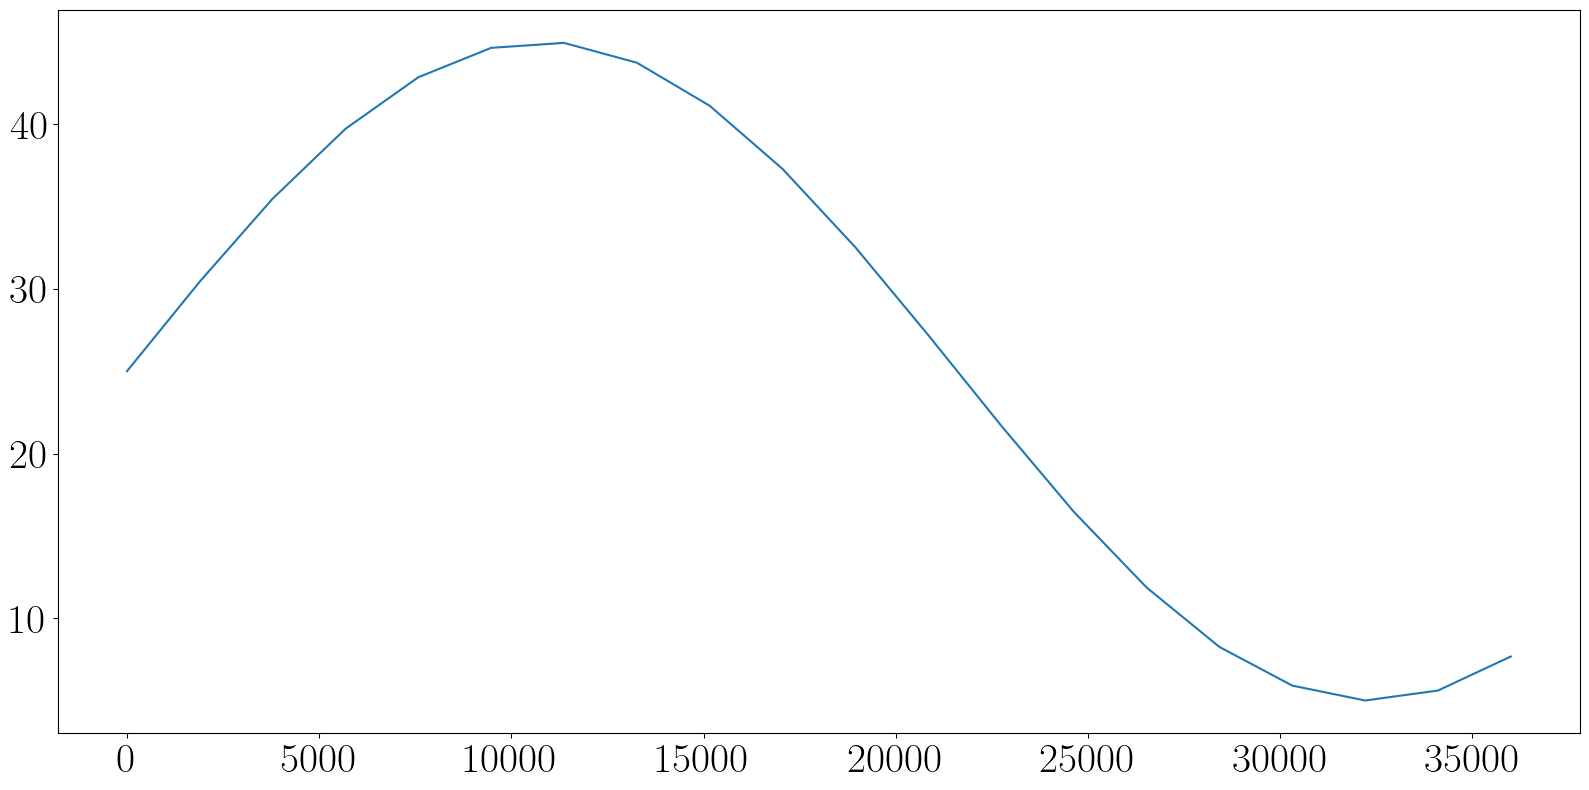

In [167]:
plt.figure()
plt.plot(t, z)

### Ajout de bruit sur les positions 

In [168]:
sigma_GPS = 5 # incertitude sur la position GPS en WGS84
sigma_x = sigma_GPS / np.sqrt(2)        # Hypothèse erreurs en x et y indépendantes et égales (sigma_x = sigma_y)
sigma_y = sigma_x
sigma_z = sigma_x

x_s = x + np.random.normal(loc=0, scale=sigma_x, size=x.size)
y_s = y + np.random.normal(loc=0, scale=sigma_y, size=y.size)
z_s = z + np.random.normal(loc=0, scale=sigma_z, size=z.size)

### Convertion en coordonnées WGS84

In [169]:
# Transformation en coordonnées WGS84
# ENU -> ECEF
X, Y, Z = enu_to_ecef(x_s, y_s, z_s, lat0, lon0, h0)
# ECEF -> WGS84
lat_s, lon_s, h_s = ecef_to_geodetic(X, Y, Z)
# Convert to deg
lat_s = np.rad2deg(lat_s)
lon_s = np.rad2deg(lon_s)

print(lon_s, lat_s, h_s)

[-3.46377942 -3.47463046 -3.45957876 -3.44855197 -3.46731097 -3.46600816
 -3.45533719 -3.47187213 -3.44618799 -3.47141909 -3.47923173 -3.46714187
 -3.464246   -3.46434555 -3.47202297 -3.46296546 -3.46471271 -3.45898428
 -3.46168887 -3.46493261] [47.68268789 47.67496149 47.67102513 47.66559203 47.67025039 47.67152554
 47.67407463 47.66758722 47.67641513 47.67616393 47.6757053  47.66617976
 47.6692374  47.66731267 47.67698324 47.66996855 47.66932621 47.6736267
 47.67025782 47.66785897] [  3.40942385   3.15160687  11.08530256  16.56843742  13.87926914
  21.10332008  21.40662976  21.0852701   21.91259514   9.5797063
  14.36353838   1.94299584  -3.83061462  -8.03535256 -14.51197079
 -16.75532669 -22.82602178 -20.28310656 -18.26383936 -11.30662325]


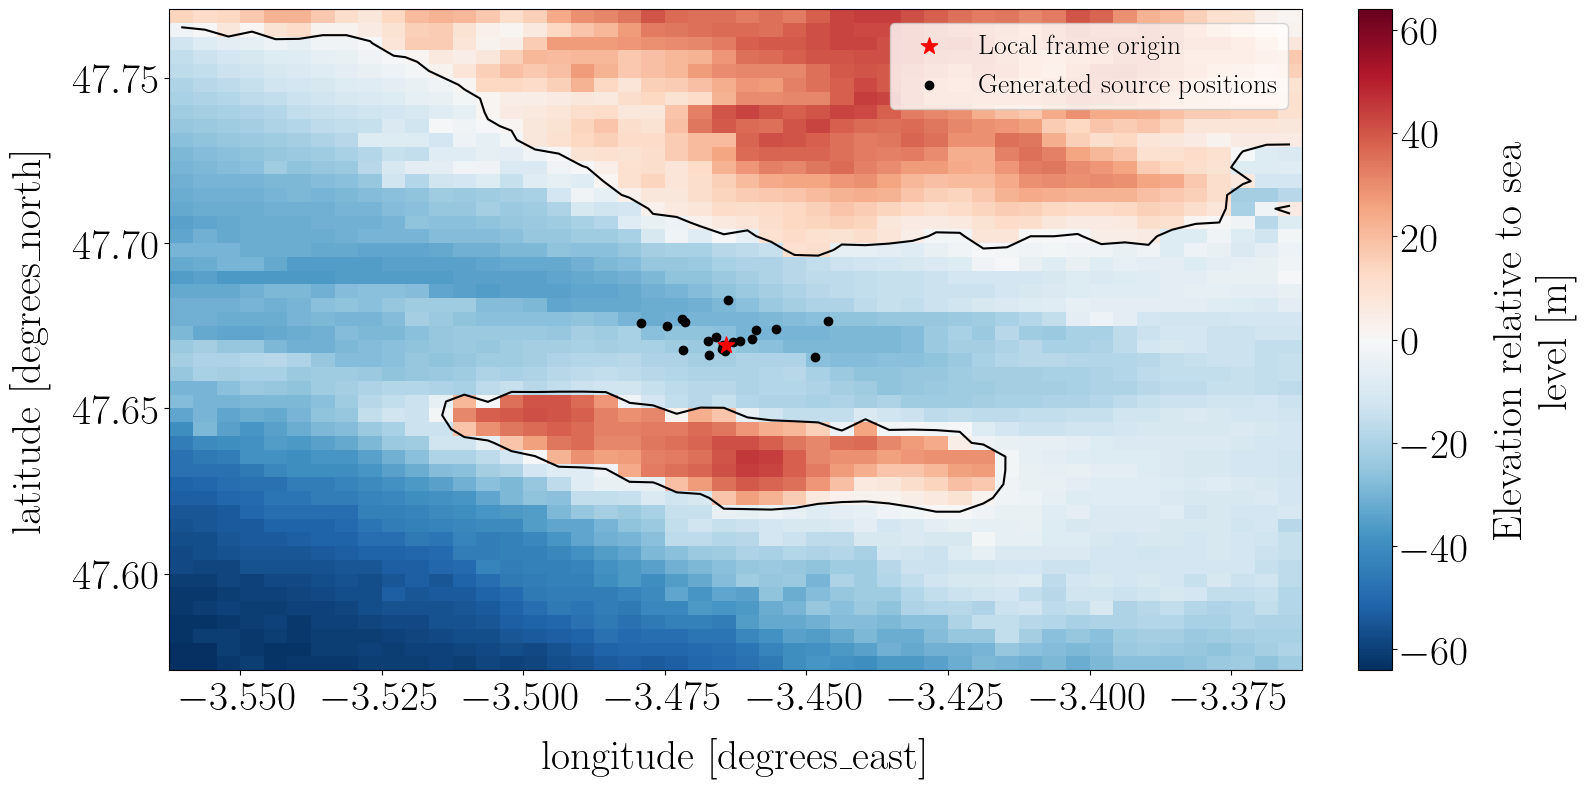

In [170]:
# Load bathy data
project_root = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd"  # Windows BAPTISTE
input_data_root = os.path.join(project_root, "data")
bathy_fpath = os.path.join(input_data_root, "bathy", "GEBCO_2021_sub_ice_topo.nc")

ds_bathy = xr.open_dataset(bathy_fpath)

# Slice data to get the area of interest
dlat_box = 0.1
dlon_box = 0.1
ds_bathy = ds_bathy.sel(
    lat=slice(
        pos0.lat - dlat_box,
        pos0.lat + dlat_box,
    ),
    lon=slice(
        pos0.lon - dlon_box,
        pos0.lon + dlon_box,
    ),
)

ds_bathy.elevation.plot()
# Add contours
plt.contour(
    ds_bathy.lon, ds_bathy.lat, ds_bathy.elevation, levels=[-0], colors="black"
)
# Repère local
plt.scatter(
    pos0.lon,
    pos0.lat,
    color="red",
    label="Local frame origin",
    marker="*",
    s=150,
    zorder=2
)
# Positions des sources
plt.scatter(lon_s, lat_s, color="black", label="Generated source positions", zorder=1)
plt.legend()

## Calcul des distances à l'OBS 1

In [171]:
obs_id = "t5"
obs_pos = apriori_pos_enu.loc[obs_id]

d_s = np.sqrt((obs_pos.e - x_s) ** 2 + (obs_pos.n - y_s) ** 2 + (obs_pos.u - z_s) ** 2)

In [172]:
d_s

array([3983.07141672, 4302.303567  , 3090.64727565, 2127.62143434,
       3619.08029531, 3565.84885021, 2936.08759933, 3889.8116416 ,
       2513.39769389, 4127.0239502 , 4655.47994106, 3514.2964807 ,
       3367.54599137, 3327.89993972, 4204.69387264, 3296.25618003,
       3403.86967436, 3158.79490261, 3213.72462344, 3383.01292812])

## Calcul des temps d'arrivée


In [173]:
# Calcul du temps d'arrivée 
c = 1500
t_s = d_s / c

In [174]:
t_s

array([2.65538094, 2.86820238, 2.06043152, 1.41841429, 2.4127202 ,
       2.37723257, 1.95739173, 2.59320776, 1.67559846, 2.7513493 ,
       3.10365329, 2.34286432, 2.24503066, 2.21859996, 2.80312925,
       2.19750412, 2.26924645, 2.10586327, 2.14248308, 2.25534195])

### Ajout du bruit sur les temps d'arrivée

In [175]:
sigma_t = 1 * 1e-3  # 1 ms 

t_s = t_s + np.random.normal(loc=0, scale=sigma_t, size=t_s.size)

# Estimation de la position par moindres carrés

#### Définition du problème des moindres carrés non linéaire 

In [176]:
def f(X, X_s):
    """
    Parameters
    ----------
    X : array
        [y, x, z] position of the hydrophone to estimate in the local reference frame
    X_s : 2D array
        [y, x, z] positions of the source

    """
    x, y, z = X
    x_s, y_s, z_s = X_s[:, 0], X_s[:, 1], X_s[:, 2]
    d2 = (x - x_s) ** 2 + (y - y_s) ** 2 + (z - z_s) ** 2
    return d2


def jac(X, X_s):
    """
    Parameters
    ----------
    X : array
        [y, x, z] position of the hydrophone to estimate in the local reference frame
    X_s : 2D array
        [y, x, z] positions of the source
    """
    x, y, z = X
    x_s, y_s, z_s = X_s[:, 0], X_s[:, 1], X_s[:, 2]

    df_dx = 2 * (x - x_s)
    df_dy = 2 * (y - y_s)
    df_dz = 2 * (z - z_s)
    J = np.array([df_dx, df_dy, df_dz]).T
    return J

In [179]:
# Position a priori 
X_0 = np.array([obs_pos.e, obs_pos.n, obs_pos.u])
print(X_0)
# Position succesives de la source 
X_s = np.stack((x_s, y_s, z_s)).T
# k iterator 
k = np.arange(X_s.shape[0])

# Weighting matrix
# W = np.diag(1 / y_var)
y = (t_s * c) ** 2 
W = np.eye(len(y))


X_hat, dY_hat, cost_hat, SigmaXhat, sigma02hat = calc_wls(Y=y, t=X_s, X_0=X_0, W=W, fct=f, jac=jac,tol=1e-6, verbose=False)
print(f"Estimated position : x = {X_hat[0]}, y = {X_hat[1]}, z = {X_hat[2]}")
print(f"Residuals : {dY_hat}")
print(f"Final cost : {cost_hat}")
print(SigmaXhat)

[3254.83817932 -832.9651269    -3.65956356]
Estimated position : x = 3254.900856319556, y = -834.0391004870113, z = 48.51658682000344
Residuals : [-23860.64110111   9926.24173334   5907.87124524   2251.00396277
  -8411.80399335 -22635.60546593   -968.94260418   6642.74156836
   7202.68106996  18532.6575403     855.32633691   -699.32727576
  -3303.0113506   -7903.17795022  25522.77904242  -4901.16359203
   4381.46649256  -3848.01570702  -3453.16320435  -7893.87737349]
Final cost : 2589626512.7301373
[[ 1.59022546e+00  2.86864777e+00 -6.44034716e+01]
 [ 2.86864777e+00  8.01282913e+00 -2.16538994e+01]
 [-6.44034716e+01 -2.16538994e+01  8.29107556e+03]]


#### Illustration des résultats

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


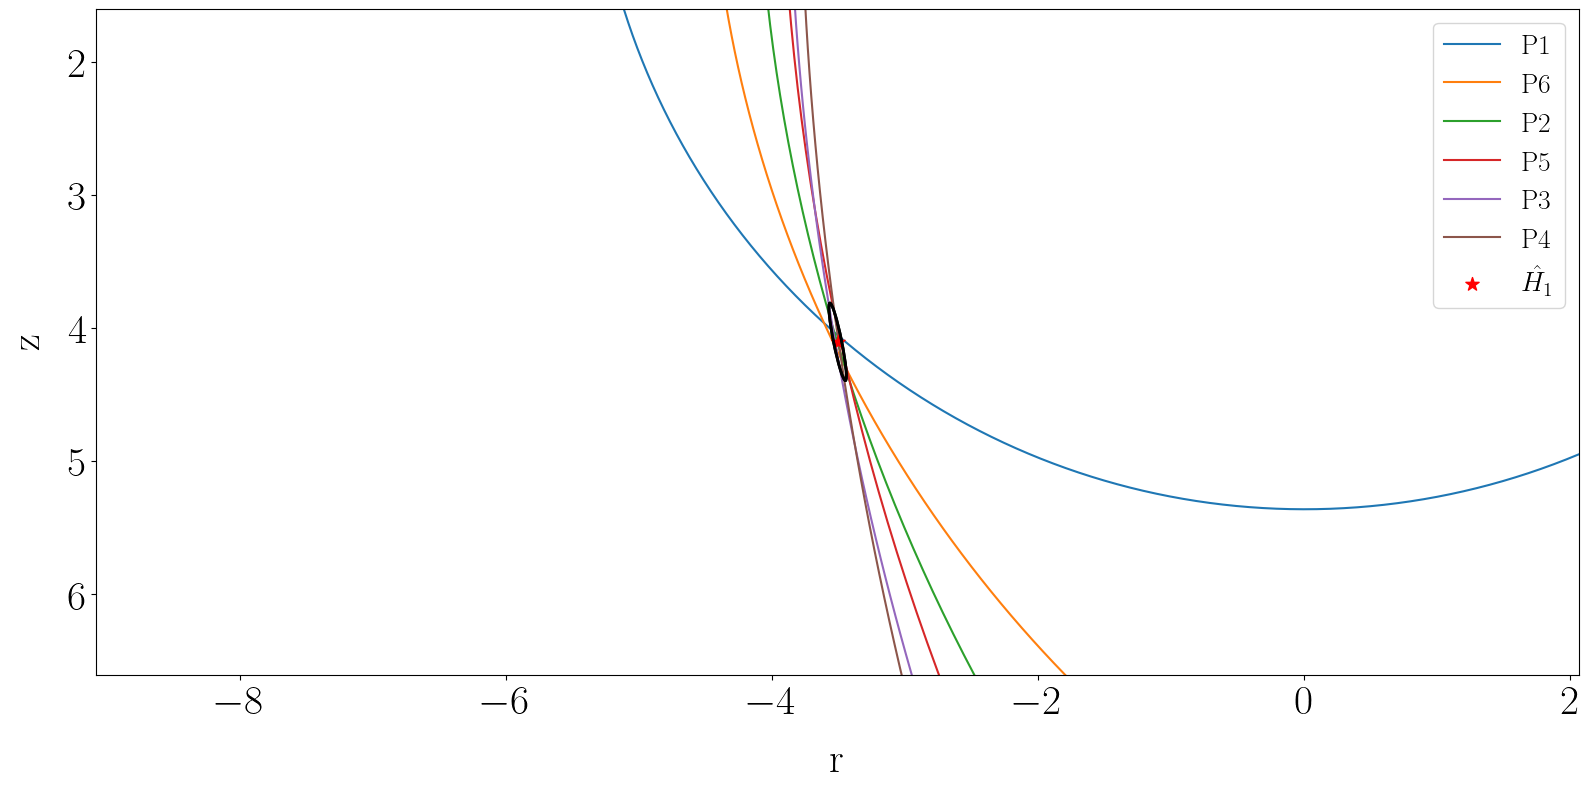

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


In [ ]:
# Illustration
first_iter = True # Show only first iteration 
theta = np.linspace(0, 2*np.pi, 1000)
for i in range(1, 6):

    hydro_to_position = f"H{i}"
    hydro_to_position_label = f"H_{i}"

    plt.figure()
    for ip, rp in enumerate(all_dists_sorted):
        plt.scatter(rp, 0)
        r = np.sqrt(d2_obs[hydro_to_position][ip])
        rc = r * np.cos(theta) + rp
        zc = r * np.sin(theta) + 0
        plt.plot(rc, zc,  label=src_label_sorted[ip])

    # # A priori position
    # rh, zh = hydro_apriori_pos[hydro_to_position]
    # # print(rh, zh)
    # plt.scatter(rh, zh, marker="s", s=100, color="k", label=hydro_to_position + r"$_{apriori}$")
    # Estimated position
    rhe, zhe = hydro_pos_hat[hydro_to_position]
    plt.scatter(
        rhe,
        zhe,
        marker="*",
        s=100,
        color="r",
        label=r"$\hat{" + hydro_to_position_label + r"}$",
        zorder=10,
    )
    plt.legend()

    # Add confidence ellipse
    alpha = 0.95
    # nombre d'observations
    nobs = y.shape[0]
    # nombre de paramètres inconnus
    nparams = hydro_pos_hat[hydro_to_position].shape[0]
    ddl = nobs - nparams 
    draw_ellipse(X=hydro_pos_hat[hydro_to_position], SigmaX=hydro_pos_hat_sigmaX[hydro_to_position], ddl=ddl, alpha=alpha, title="", color="k", fac=1)

    ax = plt.gca()
    ax.axis("equal")
    plt.xlabel("r")
    plt.ylabel("z")
    # plt.xlim(-10, 40)
    # plt.ylim(-5, 45)
    plt.xlim(rhe - 2.5, rhe + 2.5)
    plt.ylim(zhe - 2.5, zhe + 2.5)
    ax.invert_yaxis()

    fpath = os.path.join(
        img_root, f"{hydro_to_position}_estimated_position.png"
    )
    plt.savefig(fpath)

    if first_iter: 
        plt.show()
        first_iter = False 
    # else:
    plt.close('all')

C:\Users\baptiste.menetrier\Desktop\devPy\phd\misc.py:797: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


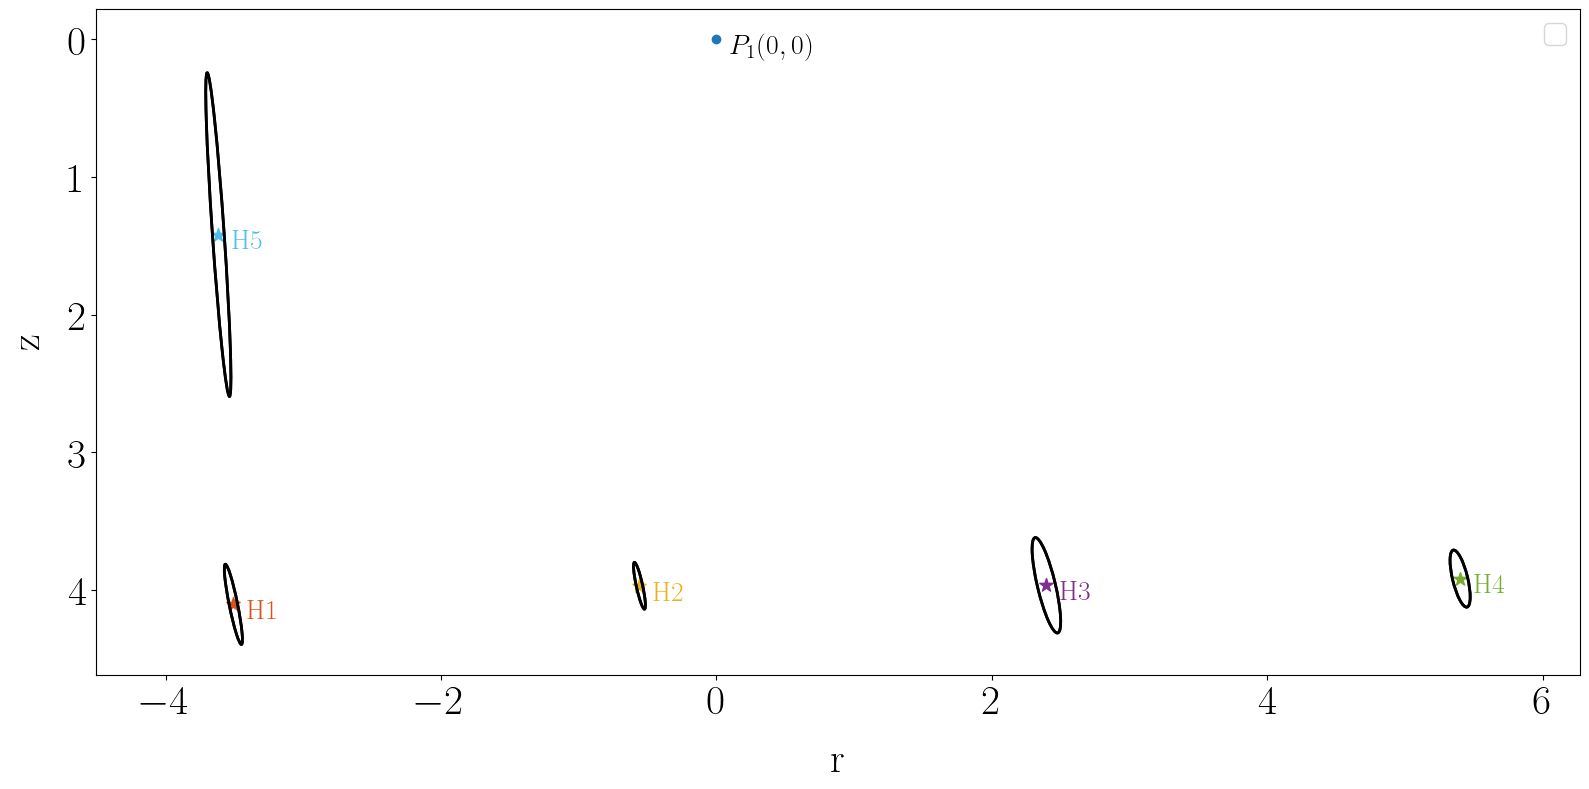

In [ ]:
# Illustration de toutes les positions
plt.figure()
for i in range(1, 6):

    hydro_to_position = f"H{i}"
    hydro_to_position_label = f"H{i}"

    # A priori position
    # Estimated position
    rhe, zhe = hydro_pos_hat[hydro_to_position]
    plt.scatter(
        rhe,
        zhe,
        marker="*",
        s=100,
        color=color(i),
        # label=r"$\hat{" + hydro_to_position_label + r"}$",
        zorder=10,
    )
    plt.annotate(hydro_to_position_label, (rhe, zhe), (rhe+0.1, zhe+0.1), fontsize=20, color=color(i))

    # Add confidence ellipse
    alpha = 0.95
    # nombre d'observations
    nobs = y.shape[0]
    # nombre de paramètres inconnus
    nparams = hydro_pos_hat[hydro_to_position].shape[0]
    ddl = nobs - nparams
    draw_ellipse(
        X=hydro_pos_hat[hydro_to_position],
        SigmaX=hydro_pos_hat_sigmaX[hydro_to_position],
        ddl=ddl,
        alpha=alpha,
        title="",
        color="k",
        fac=1,
    )

ax = plt.gca()
ax.axis("equal")
ax.invert_yaxis()
plt.xlabel("r")
plt.ylabel("z")

# Plot frame 
plt.scatter(0, 0, marker="o")
plt.annotate(r"$P_1 (0, 0) $", (0, 0), (0+0.1, 0+0.1), fontsize=20, color="k")

# plt.xlim(-10, 40)
# # plt.ylim(-5, 45)
# plt.xlim(rhe - 2.5, rhe + 2.5)
# plt.ylim(zhe - 2.5, zhe + 2.5)

# plt.legend()

fpath = os.path.join(img_root, f"all_estimated_position.png")
plt.savefig(fpath)


#### Sauvegarde des résultats

In [ ]:
# Save estimated positions
df_hydro_pos = pd.DataFrame.from_dict(hydro_pos_hat, orient="index", columns=["r", "z"])
# Set Hi column as index 
df_hydro_pos.index.name = "h_index"
df_hydro_pos.to_csv(os.path.join(params.root_data, "hydro_positions", "hydrophones_estimated_positions.csv"))

# BILAN 

Dans ce notebook les hydrophones du bassin de l'Ifremer sont positionnés à l'aide d'une résolution par moindres carrés non linéaires exploitant les temps d'arrivée des signaux propagés depuis les positions de référence de la source P1 à P6. 

Les positions P1 à P6 sont supposées connues, le repère est centré sur P1 et les positions Pi et Pi+1 sont espacées de 5m. La célérité est fixée à une valeur constante c0 = 1500m. 

Il avait été envisagé d'utiliser les relevés de températures fait par un profileur Argo quelques semaines avant les essais Fiberscope dans le bassin afin de calculer la célérité équivalente dans le bassin pour l'inversion des positions. Cette option a été explorée et conduit à des résultats dégradés. Ces faibles performances avec la célérité équivalente résultent probablement des fortes incertitudes autour du profil de température utilisé : 

* Deux températures sont utilisées (fond et surface) et on fait l'hypothèse que la température de fond est celle à 20 m (sans certitude)
* Le profil de température est supposé linéaire or ce n'est pas le cas si les conditions de température varient rapidement dans le hangar en raison de l'inertie de la masse d'eau du bassin. 
* On suppose que le profil de température mesuré quelques semaines avant les essais n'a pas évolué, c'est une hypothèse très forte. 



# Left over

Les bouts de code ci-dessous sont laissés "au cas où" mais ne sont pas utilisable en l'état. En particulier, une partie du code ci-dessous illustre l'échec de la détection du temps d'arrivée après compression d'impulsion. L'hypothèse formulée par Samuel P. pour expliquer cet échec repose sur l'utilisation d'un signal source erroné, c'est-à-dire, légèrement différent du signal source effectivement généré sur la source. 

Il était prévu de creuser le sujet avec Alain en récupérant le code à l'origine des signaux émis, mais cela n'a pas été fait pour l'heure ce sujet n'étant clairement pas une priorité de la thèse. 

### Localisation des hydrophones par TDOA 

On cherche à estimer la position $\begin{pmatrix} r \\ z \end{pmatrix}$ de l'hydrophone, par exemple $H_1$.

On dispose des enregistrements correspondant aux positions de la source de $P_0$ à $P_5$ noté $P_j \begin{pmatrix} r_j \\ z_j \end{pmatrix}$. L'origine du repère est choisie en $P_0$ de telle sorte que $r_j = j \times \Delta_r, z_j = 0$, $j \in [0, 5]$.

Soit $j \in [0, 5]$,

$$
D_j^2 = \lVert P_jH_1\rVert^2 = (r_j - r)^2 + (z-z_j)^2 = (r_j - r)^2 + z^2   
$$

Pour la position de référence (j=0) : 

$$
(1) \quad \quad D_0^2 = (r_0 - r)^2 + z^2 = r_0^2 - 2r_0r + z^2  = z^2
$$

Or on peut écrire pour $j \in [1, 5]$ :

$$
(2) \quad \quad D_j^2 = (D_0 + \delta D_j)^2 = D_0^2 + 2D_0 \delta D_j + D_j^2
$$

Et, 

$$
(3) \quad \quad  D_0^2 + 2D_0 \delta D_j + D_j^2 =  r_j^2 - 2r_jr + z^2 
$$

Ainsi, on peut écrire (3) - (2) : 

$$
(4) \quad \quad  2D_0 \delta D_j + D_j^2 =  r_j^2 - 2r_jr
$$

En pratique on mesure des différences de temps d'arrivée $\delta T_j = T_j - T_0$, $\delta D_j = c \delta T_j$. 

Et donc (4) s'écrit :
$$
(4) \quad \quad  2D_0 c \delta T_j + (c \delta T_j)^2 =  r_j^2 - 2r_jr
$$

On a donc 3 inconnues ($D_0, c, r$) pour 5 équations ($j \in [1, 5]$).



### Détection après compression d'impulsion 

Piste abandonnée, inutile pour l'application simple visée 

In [ ]:
# Apply wave compression
t_pulse = fs_sweep.pulse_length
t = time.sel(time=slice(0, t_pulse)).values
f0 = fs_sweep.fmin
f1 = fs_sweep.fmax
sig_source = sp.chirp(t, f0=f0, f1=f1, t1=t_pulse, method="linear")


spec_source = np.fft.fft(sig_source, n=len(time))
f = np.fft.fftfreq(len(time), d=1 / fs)

# Smooth with a gaussian window
fc = (f1 - f0) / 2 + f0
bw = (f1 - f0) * 1
gauss_win_neg = np.exp(-0.5 * ((f + fc) / (bw / 4)) ** 2)
gauss_win_pos = np.exp(-0.5 * ((f - fc) / (bw / 4)) ** 2)
gauss_win = gauss_win_neg * (f < 0) + gauss_win_pos * (f >= 0)
spec_source_smooth = spec_source * gauss_win

# Time signals 
sig_source = np.fft.ifft(spec_source, n=len(time)).real
sig_source_smooth = np.fft.ifft(spec_source_smooth, n=len(time)).real

# Compute cross-correlation
mf = []

for i_sig in range(signals.shape[0]): 
    sig = signals[i_sig]
    spec_sig = np.fft.fft(sig, n=len(time))
    mf_spec = spec_sig * np.conj(spec_source_smooth)    
    mf_sig = np.fft.ifft(mf_spec)
    mf.append(mf_sig.real)

mf = np.array(mf)

# lags =
lags = (
    sp.correlation_lags(sig.size, sig_source_smooth.size, mode="same") * 1 / fs
)

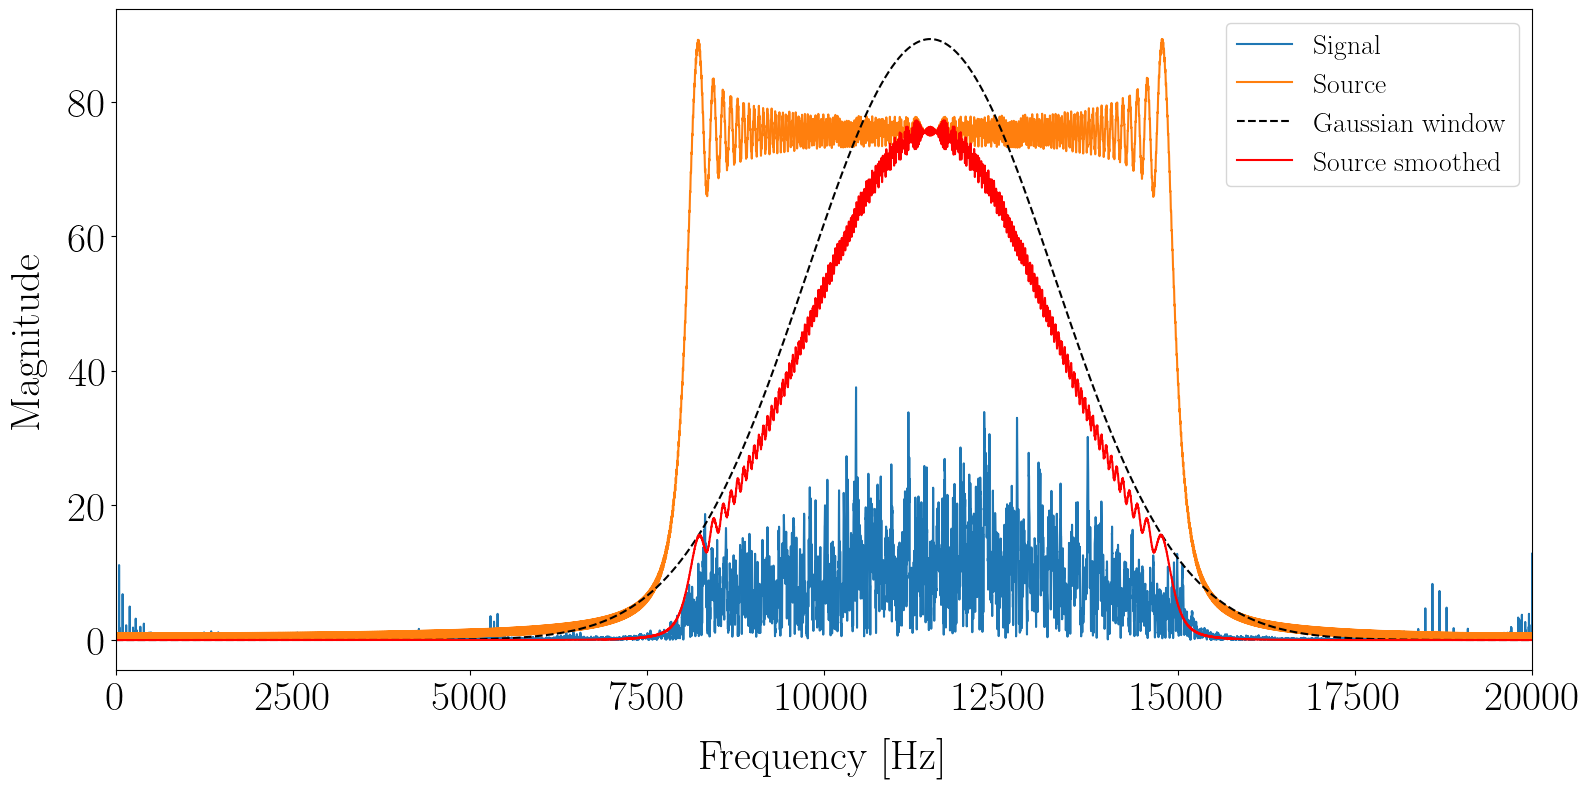

In [ ]:
x_f = np.fft.fft(sig)
f = np.fft.fftfreq(n=sig.size, d=1 / ds_rtf.fs)

plt.figure()
plt.plot(np.fft.fftshift(f), np.fft.fftshift(np.abs(x_f)), label="Signal")
plt.plot(np.fft.fftshift(f), np.fft.fftshift(np.abs(spec_source)), label="Source")
plt.plot(
    np.fft.fftshift(f),
    np.fft.fftshift(gauss_win * np.max(np.abs(spec_source))),
    "--k",
    label="Gaussian window",
)
plt.plot(
    np.fft.fftshift(f),
    np.fft.fftshift(np.abs(spec_source_smooth)),
    "-r",
    label="Source smoothed",
)
plt.xlim([0, fs/2])
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude")
plt.legend()


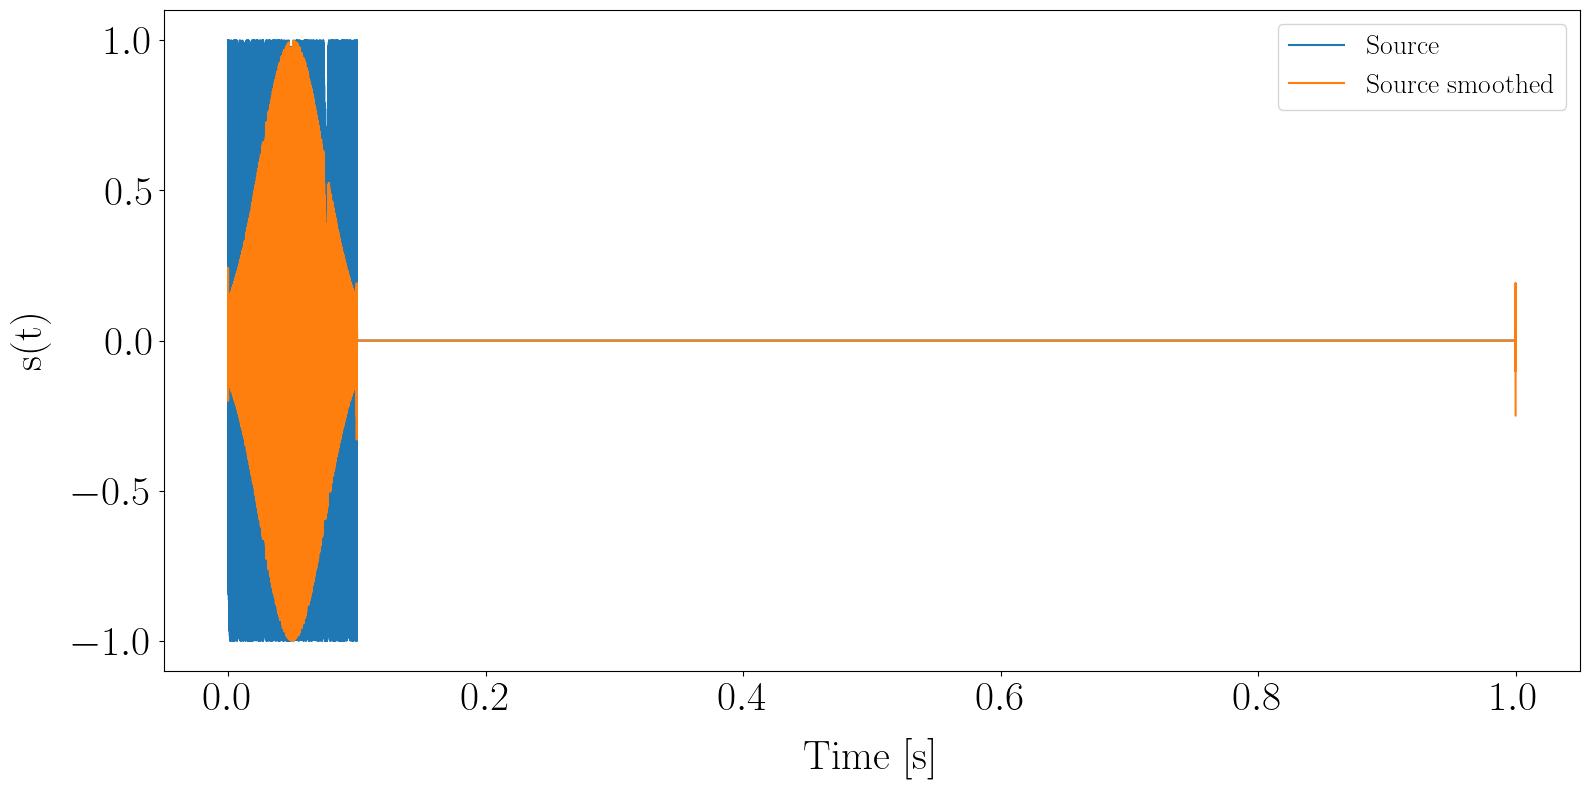

In [ ]:
plt.figure()
plt.plot(time, sig_source, label="Source")
plt.plot(time, sig_source_smooth, label="Source smoothed")
plt.xlabel("Time [s]")
plt.ylabel("s(t)")
plt.legend()

(0.0, 0.025)

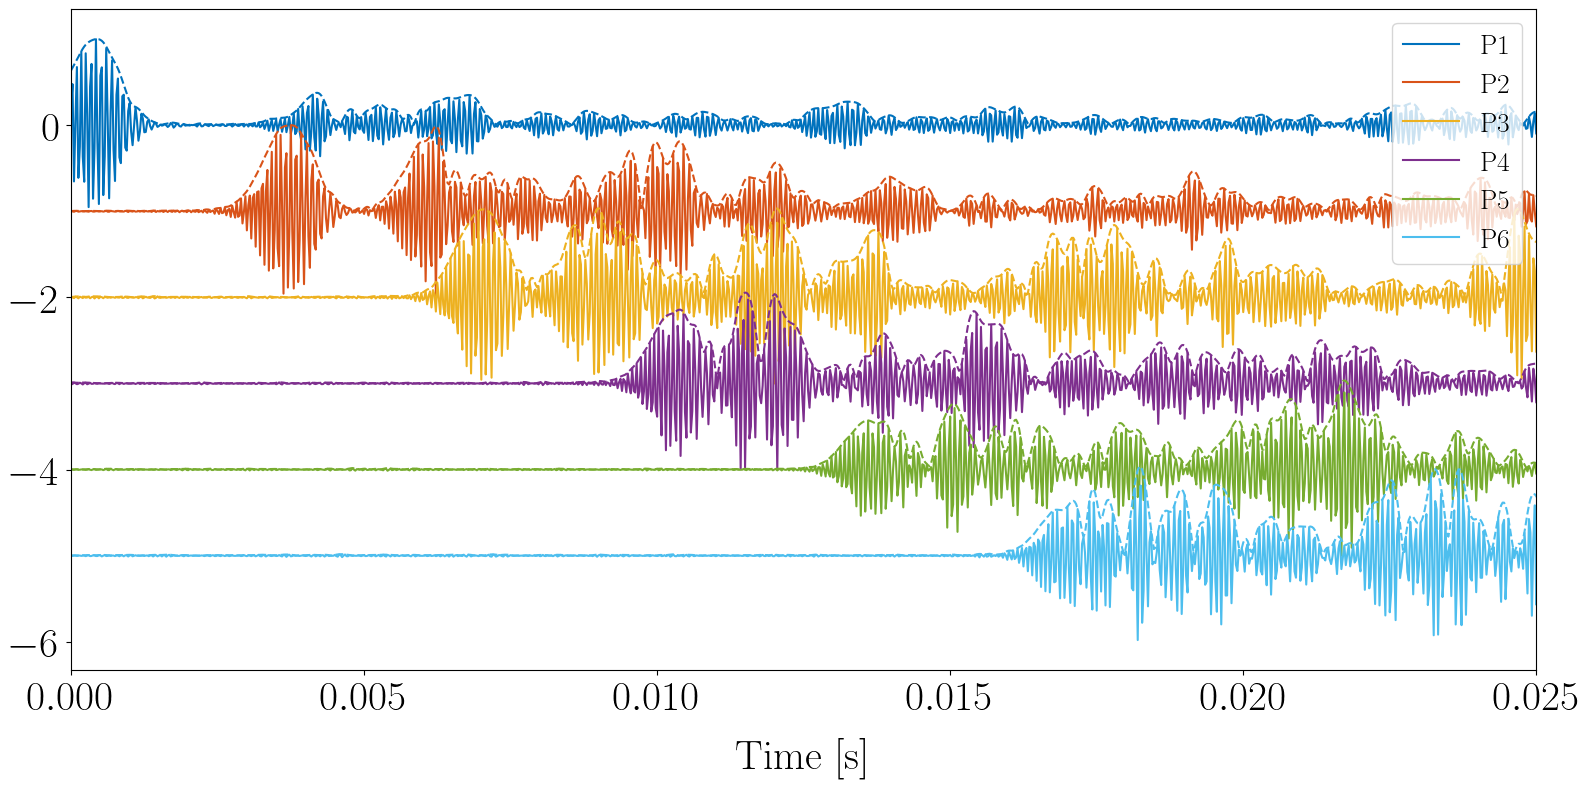

In [ ]:
# Stack plot
delta_y = 1
plt.figure()
for i, mf_sig in enumerate(mf):
    mf_sig_n = mf_sig / np.max(np.abs(mf_sig))
    plt.plot(time, mf_sig_n - i * delta_y, label=src_labels[i], color=color(i))
    mf_sig_n_env = np.abs(sp.hilbert(mf_sig_n))
    plt.plot(time, mf_sig_n_env - i * delta_y, color=color(i), linestyle='--')
plt.legend(loc="upper right")
plt.xlabel("Time [s]")
# plt.ylabel("Amplitude (a.u.)")
plt.xlim([0, 0.025])

Text(0.5, 0, 'Time [s]')

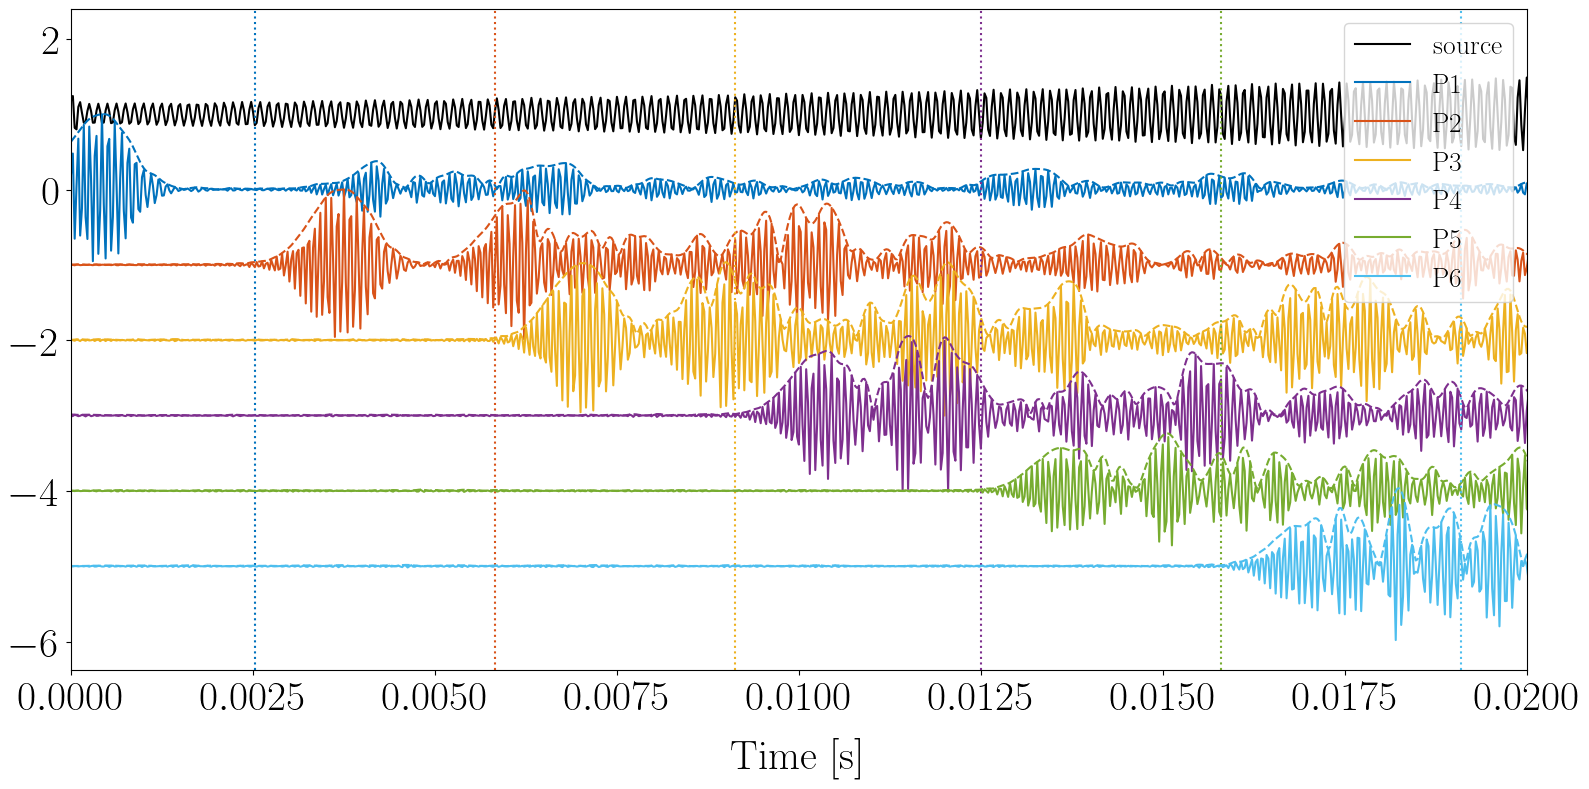

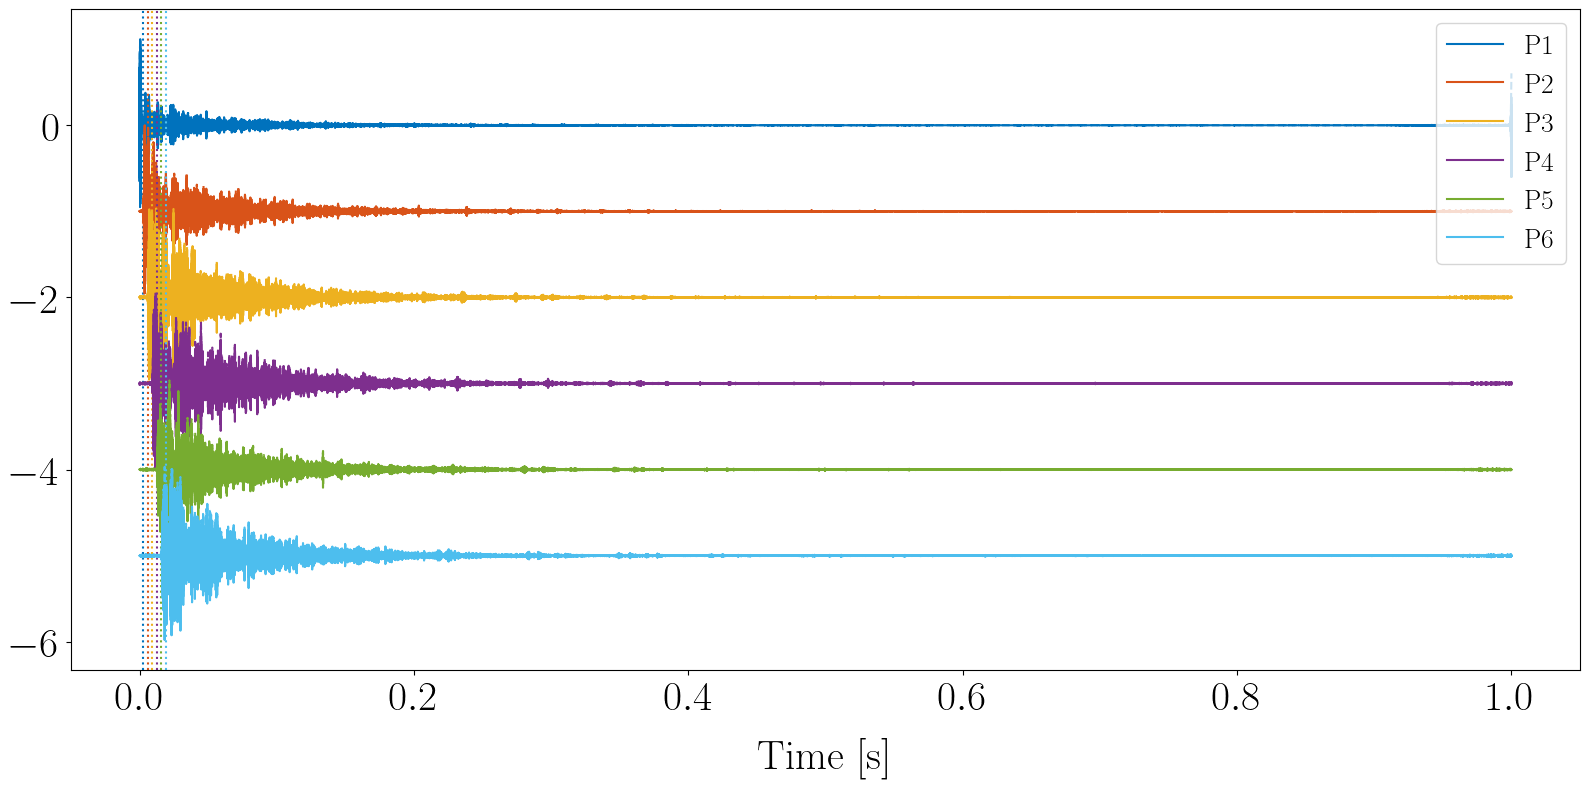

In [ ]:
# Stack plot
delta_y = 1
plt.figure()
plt.plot(time, sig_source_smooth + 1 * delta_y, label="source", color="k")
for i, mf_sig in enumerate(mf):
    mf_sig_n = mf_sig / np.max(np.abs(mf_sig))
    plt.plot(time, mf_sig_n - i * delta_y, label=src_labels[i], color=color(i))
    mf_sig_n_env = np.abs(sp.hilbert(mf_sig_n))
    plt.plot(time, mf_sig_n_env - i * delta_y, color=color(i), linestyle="--")
    # Find arrival time
    xr_sir = xr.DataArray(signals[i, :], coords=[time], dims=["time"])
    td_env = direct_arrival_env(sig=xr_sir, fs=fs, c=c0, plot=False)
    plt.axvline(td_env, color=color(i), linestyle=":")

plt.legend(loc="upper right")
plt.xlabel("Time [s]")
# plt.ylabel("Amplitude (a.u.)")
plt.xlim([0, 0.02])

# Stack plot
delta_y = 1
plt.figure()
for i, mf_sig in enumerate(mf):
    mf_sig_n = mf_sig / np.max(np.abs(mf_sig))
    plt.plot(time, mf_sig_n - i * delta_y, label=src_labels[i], color=color(i))
    mf_sig_n_env = np.abs(sp.hilbert(mf_sig_n))
    plt.plot(time, mf_sig_n_env - i * delta_y, color=color(i), linestyle="--")
    # Find arrival time
    xr_sir = xr.DataArray(signals[i, :], coords=[time], dims=["time"])
    td_env = direct_arrival_env(sig=xr_sir, fs=fs, c=c0, plot=False)
    plt.axvline(td_env, color=color(i), linestyle=":")

plt.legend(loc="upper right")
plt.xlabel("Time [s]")
# plt.ylabel("Amplitude (a.u.)")
# plt.xlim([0, 0.02])